In [ ]:
import kagglehub
path = kagglehub.dataset_download("tthien/shanghaitech")

print(path)

/kaggle/input/shanghaitech


In [ ]:
# !pip install scipy opencv-python-headless

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import os
import scipy.io as sio
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import Sequence
from tensorflow.keras import layers, models


In [ ]:
class ShanghaiTechDataset(Sequence):
    def __init__(self, image_dir, gt_dir, batch_size=4, img_size=(256, 256)):
        self.image_paths = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.jpg')])
        self.gt_paths = [
            os.path.join(gt_dir, 'GT_' + os.path.basename(f).replace('.jpg', '.mat'))
            for f in self.image_paths
        ]
        self.batch_size = batch_size
        self.img_size = img_size

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_x = self.image_paths[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = self.gt_paths[idx * self.batch_size:(idx + 1) * self.batch_size]

        imgs, dens = [], []
        for img_path, mat_path in zip(batch_x, batch_y):
            img = load_img(img_path)
            img = img.resize(self.img_size)
            img = img_to_array(img) / 255.0

            dmap = get_density_map_from_mat(mat_path, img.shape[:2])
            dmap = cv2.resize(dmap, self.img_size)
            dmap = np.expand_dims(dmap, axis=-1)

            imgs.append(img)
            dens.append(dmap)

        return np.array(imgs), np.array(dens)

def get_density_map_from_mat(mat_path, shape, sigma=15):
    mat = sio.loadmat(mat_path)
    points = mat['image_info'][0][0][0][0][0]  # (N, 2)
    density_map = np.zeros(shape, dtype=np.float32)
    for point in points:
        x = min(int(point[0]), shape[1] - 1)
        y = min(int(point[1]), shape[0] - 1)
        density_map[y, x] = 1
    density_map = cv2.GaussianBlur(density_map, (0, 0), sigma)
    return density_map

def build_unet(input_shape=(256, 256, 3)):
    inputs = tf.keras.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)

    # Decoder
    u1 = layers.UpSampling2D()(c3)
    u1 = layers.concatenate([u1, c2])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2, c1])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(c5)

    output = layers.Conv2D(1, 1, activation=None)(c5)

    return tf.keras.Model(inputs, output)

In [ ]:
train_dataset = ShanghaiTechDataset(
    image_dir='/kaggle/input/shanghaitech/ShanghaiTech/part_A/train_data/images',
    gt_dir='/kaggle/input/shanghaitech/ShanghaiTech/part_A/train_data/ground-truth',
    batch_size=32
)

val_dataset = ShanghaiTechDataset(
    image_dir='/kaggle/input/shanghaitech/ShanghaiTech/part_A/test_data/images',
    gt_dir='/kaggle/input/shanghaitech/ShanghaiTech/part_A/train_data/ground-truth',
    batch_size=32
)
def count_loss(y_true, y_pred):
    density_loss = tf.keras.losses.MSE(y_true, y_pred)
    count_true = tf.reduce_sum(y_true, axis=[1, 2, 3])
    count_pred = tf.reduce_sum(y_pred, axis=[1, 2, 3])
    count_loss = tf.keras.losses.MSE(count_true, count_pred)
    return density_loss + 0.001 * count_loss

model = build_unet()
model.compile(optimizer='adam', loss=count_loss, metrics=['mae'])

model.fit(train_dataset, validation_data=val_dataset, epochs=30)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 157s 9s/step - loss: 65570.2266 - mae: 0.0625 - val_loss: 52.8051 - val_mae: 0.0049
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: 50.6532 - mae: 0.0045 - val_loss: 21.7906 - val_mae: 0.0035
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: 22.5073 - mae: 0.0035 - val_loss: 21.2713 - val_mae: 0.0035
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: 22.0309 - mae: 0.0034 - val_loss: 19.7422 - val_mae: 0.0033
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - loss: 20.9726 - mae: 0.0032 - val_loss: 21.3576 - val_mae: 0.0034
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: 17.2492 - mae: 0.0033 - val_loss: 22.4505 - val_mae: 0.0036
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: 22.7302 - mae: 0.0034 - val_loss: 21.3243 - val_mae: 0.0036
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: 18.2700 - mae: 0.0033 - val_loss: 20.5077 - val_mae: 0.0036
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 931ms/step


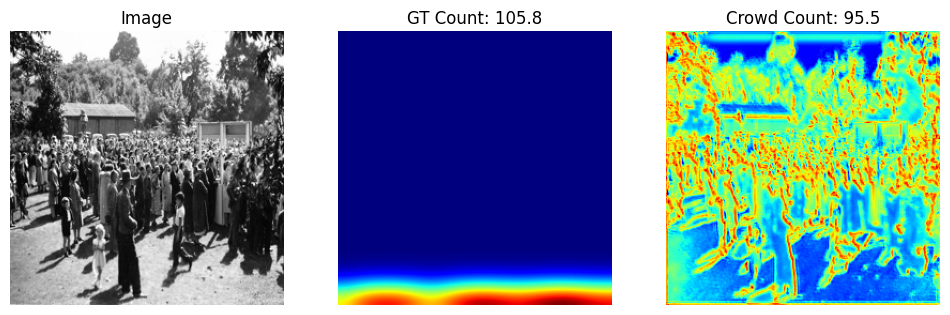

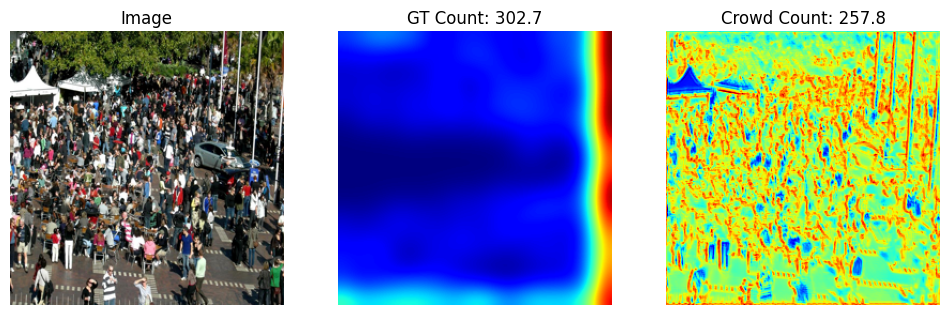

In [ ]:
import matplotlib.pyplot as plt

imgs, gt_dmaps = val_dataset[0]
pred_dmaps = model.predict(imgs)

for i in range(2):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(imgs[i])
    plt.title("Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(gt_dmaps[i].squeeze(), cmap='jet')
    plt.title(f"GT Count: {np.sum(gt_dmaps[i]):.1f}")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_dmaps[i].squeeze(), cmap='jet')
    plt.title(f"Crowd Count: {np.sum(pred_dmaps[i]):.1f}")
    plt.axis('off')

    plt.show()
